In [1]:
import os

# Tumcha Kaggle Username ani API Key ithhe taka
os.environ['KAGGLE_USERNAME'] = "kusumithnimsara"
os.environ['KAGGLE_KEY'] = "KGAT_90d2d83900db481e19bcc4dafb609026"

# Kaggle dataset download kara
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

# ZIP file extract kara
!unzip -q eye-diseases-classification.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:40<00:00, 19.2MB/s]



In [2]:
!pip install split-folders

In [3]:
import os
import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                              auc, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Environment setup completed successfully.")

Environment setup completed successfully.


In [5]:
DATASET_DIR = "/content/dataset/dataset"  # Corrected path for Kaggle dataset
SPLIT_DIR = "/content/dataset_split"

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

if os.path.exists(DATASET_DIR):
    splitfolders.ratio(
        DATASET_DIR,
        output=SPLIT_DIR,
        seed=SEED,
        ratio=(.7, .15, .15),
        group_prefix=None
    )

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, label_mode='categorical', image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False
)

CLASS_NAMES = train_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12),
    layers.RandomBrightness(0.12),
], name="data_augmentation")

def make_pipeline(ds, training=False):
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.cache().prefetch(tf.data.AUTOTUNE)

train_ds = make_pipeline(train_ds_raw, training=True)
val_ds   = make_pipeline(val_ds_raw, training=False)
test_ds  = make_pipeline(test_ds_raw, training=False)

train_labels = []
for _, y in train_ds_raw.unbatch():
    train_labels.append(np.argmax(y.numpy()))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Data processing pipeline ready.")

Copying files: 4217 files [00:05, 818.57 files/s]

Found 2949 files belonging to 5 classes.


Found 631 files belonging to 5 classes.
Found 637 files belonging to 5 classes.
Data processing pipeline ready.


In [6]:
def build_densenet121(num_classes, img_size=(224, 224)):
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=img_size + (3,)
    )

    # Freeze all layers except conv5 block
    for layer in base_model.layers:
        if not layer.name.startswith('conv5'):
            layer.trainable = False
        else:
            layer.trainable = True

    inputs = layers.Input(shape=img_size + (3,))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.45)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="DenseNet121_EyeDisease")
    return model, base_model

model, base_model = build_densenet121(NUM_CLASSES, IMG_SIZE)
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "DenseNet121_EyeDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,285 (27.87 MB)

 Trainable params: 2,423,813 (9.25 MB)

 Non-trainable params: 4,881,472 (18.62 MB)

In [9]:
train_labels = []
for _, y in train_ds_raw.unbatch():
    train_labels.append(np.argmax(y.numpy()))

train_labels = np.array(train_labels)
unique_classes = np.unique(train_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)

# Explicit integer mapping for class weights
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(unique_classes, class_weights)}

print("Dataset classes:", CLASS_NAMES)
print("Corrected class_weight_dict:", class_weight_dict)

Dataset classes: ['cataract', 'dataset', 'diabetic_retinopathy', 'glaucoma', 'normal']
Corrected class_weight_dict: {0: 1.015495867768595, 2: 0.9599609375, 3: 1.0472301136363635, 4: 0.9816910785619174}


In [10]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
checkpoint = callbacks.ModelCheckpoint('/content/densenet121_best.keras',
                                       monitor='val_loss', save_best_only=True)

EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.6572 - auc: 0.8977 - loss: 0.9654 - precision: 0.7205 - recall: 0.5744 - val_accuracy: 0.6957 - val_auc: 0.9305 - val_loss: 0.7854 - val_precision: 0.7505 - val_recall: 0.6101 - learning_rate: 1.0000e-04
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.8399 - auc: 0.9742 - loss: 0.4837 - precision: 0.8620 - recall: 0.8050 - val_accuracy: 0.7433 - val_auc: 0.9557 - val_loss: 0.6377 - val_precision: 0.7738 - val_recall: 0.7211 - learning_rate: 1.0000e-04
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 135ms/step - accuracy: 0.9027 - auc: 0.9898 - loss: 0.3206 - precision: 0.9178 - recall: 0.8864 - val_accuracy: 0.7940 - val_auc: 0.9679 - val_loss: 0.5409 - val_precision: 0.8102 - val_recall: 0.7781 - learning_rate: 1.0000e-04
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.9339 - auc: 0.9952 - loss: 0.2340 - precision: 0.9443 - recall: 0.9251 - val_accuracy: 0.8336 - val_auc: 0.9716 - val_loss

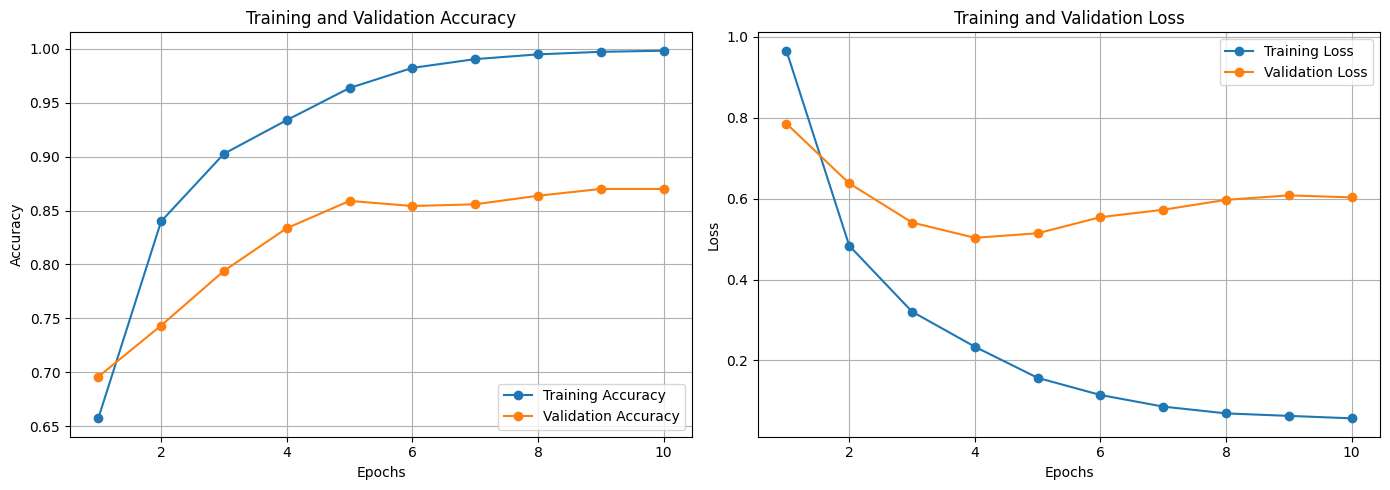

In [13]:

# PLOT TRAINING CURVES (Single Phase)

import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# 1. Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/densenet121_training_curves.png', dpi=150)
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.8163 - auc: 0.9672 - loss: 0.5554 - precision: 0.8282 - recall: 0.8022

Test Set Results: {'accuracy': 0.8163265585899353, 'auc': 0.967158854007721, 'loss': 0.5553931593894958, 'precision': 0.8282009959220886, 'recall': 0.8021978139877319}

Classification Report:

                      precision    recall  f1-score   support

            cataract       0.89      0.94      0.91       157
             dataset       0.00      0.00      0.00         0
diabetic_retinopathy       0.80      0.89      0.84       166
            glaucoma       0.88      0.64      0.74       152
              normal       0.72      0.79      0.76       162

            accuracy                           0.82       637
           macro avg       0.66      0.65      0.65       637
        weighted avg       0.82      0.82      0.81       637



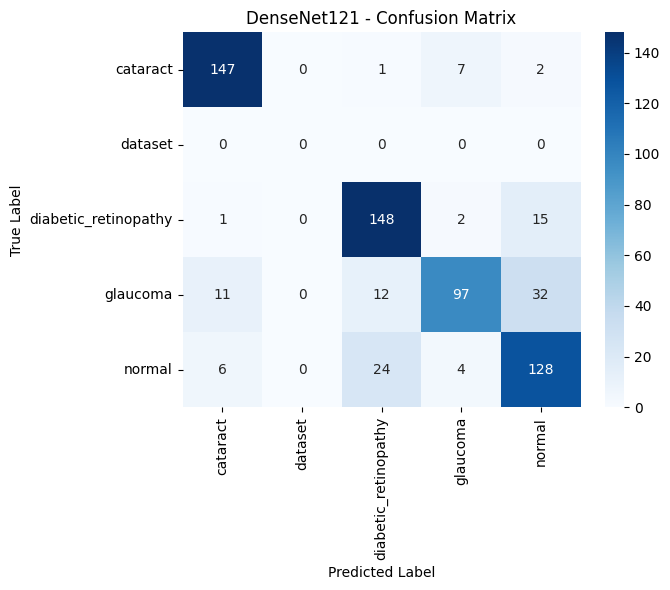

In [12]:
# 1. Final evaluation on Test Set
test_results = model.evaluate(test_ds, return_dict=True)
print("\nTest Set Results:", test_results)

# 2. Extract true labels and predicted probabilities
y_true, y_pred_probs = [], []
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred_probs.append(preds)
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true)
y_pred_probs = np.concatenate(y_pred_probs)
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# List of integer class indices matching CLASS_NAMES
all_labels = list(range(len(CLASS_NAMES)))

# 3. Print Classification Report with explicit labels
print("\nClassification Report:\n")
print(classification_report(
    y_true_labels,
    y_pred_labels,
    labels=all_labels,
    target_names=CLASS_NAMES,
    zero_division=0
))

# 4. Plot Confusion Matrix with explicit labels
cm = confusion_matrix(y_true_labels, y_pred_labels, labels=all_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DenseNet121 - Confusion Matrix')
plt.tight_layout()
plt.savefig("/content/densenet121_confusion_matrix.png", dpi=150)
plt.show()